<a href="https://colab.research.google.com/github/suparuek2405/credit-default-dl/blob/main/notebooks/02_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Baseline Models
### UCI Credit Card Default Dataset

**Goal:** Establish performance benchmarks using traditional ML models before deep learning.

Pipeline:
- Feature engineering (17 domain-specific features)
- NearMiss v3 undersampling
- Optuna hyperparameter tuning (50 trials each)
- Logistic Regression, XGBoost, LinearSVC
- Soft voting ensemble

Best ensemble AUC = target for deep learning model to beat.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from imblearn.under_sampling import NearMiss
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style("whitegrid")

print("Imports done.")

Imports done.


In [4]:
df = pd.read_csv('UCI_Credit_Card.csv')
df = df.drop('ID', axis=1)
df = df.rename(columns={'default.payment.next.month': 'target'})

print(f"Shape: {df.shape}")
print(f"Default rate: {df['target'].mean():.1%}")

Shape: (30000, 24)
Default rate: 22.1%


In [5]:
#feature engineering
def engineer_features(df):
    df = df.copy()

    pay_cols     = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                    'BILL_AMT4','BILL_AMT5','BILL_AMT6']
    pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                    'PAY_AMT4','PAY_AMT5','PAY_AMT6']

    # Payment behavior
    df['late_pay_count']  = (df[pay_cols] > 0).sum(axis=1)
    df['max_pay_status']  = df[pay_cols].max(axis=1)
    df['pay_trend']       = df['PAY_0'] - df['PAY_2']
    df['pay_trend_long']  = df['PAY_0'] - df['PAY_6']

    # Bill features
    df['avg_bill']        = df[bill_cols].mean(axis=1)
    df['avg_pay_amount']  = df[pay_amt_cols].mean(axis=1)
    df['bill_std']        = df[bill_cols].std(axis=1)
    df['pay_amt_std']     = df[pay_amt_cols].std(axis=1)
    df['bill_trend']      = df['BILL_AMT1'] - df['BILL_AMT3']
    df['bill_trend_long'] = df['BILL_AMT1'] - df['BILL_AMT6']
    df['pay_amt_trend']   = df['PAY_AMT1']  - df['PAY_AMT3']

    # Ratio features
    df['util_ratio']     = (df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['avg_util_ratio'] = (df['avg_bill']  / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['pay_ratio_1']    = (df['PAY_AMT1']  / (df['BILL_AMT1'] + 1)).clip(0, 5)
    df['pay_ratio_2']    = (df['PAY_AMT2']  / (df['BILL_AMT2'] + 1)).clip(0, 5)
    df['bill_to_pay']    = (df['avg_bill']  / (df['avg_pay_amount'] + 1)).clip(0, 50)
    df['risk_score']     = (df['util_ratio'] * df['late_pay_count']).clip(0, 20)

    # Clip dollar columns to 99th percentile
    dollar_cols = bill_cols + pay_amt_cols + [
        'avg_bill', 'avg_pay_amount', 'bill_std',
        'pay_amt_std', 'bill_trend', 'bill_trend_long',
        'pay_amt_trend', 'LIMIT_BAL'
    ]
    for col in dollar_cols:
        p01 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(p01, p99)

    # Safety check
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median())

    return df

df_eng = engineer_features(df)

print(f"Original features: 23")
print(f"Engineered features: {df_eng.shape[1]-1}")
print(f"Value range: {df_eng.drop('target',axis=1).values.min():.2f} "
      f"to {df_eng.drop('target',axis=1).values.max():.2f}")

Original features: 23
Engineered features: 40
Value range: -87948.63 to 500000.00


In [7]:
#Train/Val/Test Split
X = df_eng.drop('target', axis=1).values.astype(np.float32)
y = df_eng['target'].values.astype(np.float32)

# 70 / 15 / 15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Default rate (train): {y_train.mean():.1%}")
print(f"Default rate (val): {y_val.mean():.1%}")
print(f"Default rate (test): {y_test.mean():.1%}")

Train: (21012, 40)
Val:   (4488, 40)
Test:  (4500, 40)
Default rate (train): 22.1%
Default rate (val): 22.1%
Default rate (test): 22.1%


In [8]:
#NearMiss Undersampling
nm = NearMiss(version=3, n_neighbors=3)
X_train_nm, y_train_nm = nm.fit_resample(X_train, y_train)

print(f"Before NearMiss: {len(X_train):,} samples | "
      f"{y_train.mean():.1%} default rate")
print(f"After NearMiss:  {len(X_train_nm):,} samples | "
      f"{y_train_nm.mean():.1%} default rate")

Before NearMiss: 21,012 samples | 22.1% default rate
After NearMiss:  9,296 samples | 50.0% default rate


In [9]:
#Scale Features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_nm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train scaled: {X_train_sc.shape}")
print(f"Val scaled:   {X_val_sc.shape}")
print(f"Test scaled:  {X_test_sc.shape}")

Train scaled: (9296, 40)
Val scaled:   (4488, 40)
Test scaled:  (4500, 40)


In [10]:
def objective_lr(trial):
    C         = trial.suggest_float('C', 1e-4, 10, log=True)
    solver    = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    max_iter  = trial.suggest_int('max_iter', 500, 2000)

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train_sc, y_train_nm)
    preds = model.predict_proba(X_val_sc)[:, 1]
    return roc_auc_score(y_val, preds)

study_lr = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_lr.optimize(objective_lr, n_trials=50)

print(f"Best LR AUC:    {study_lr.best_value:.4f}")
print(f"Best LR params: {study_lr.best_params}")

Best LR AUC:    0.7528
Best LR params: {'C': 0.11198612718699313, 'solver': 'lbfgs', 'max_iter': 1863}


In [11]:
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight':  (y_train_nm == 0).sum() / (y_train_nm == 1).sum(),
        'eval_metric':       'auc',
        'random_state':      42,
        'verbosity':         0
    }
    model = XGBClassifier(**params)
    model.fit(X_train_sc, y_train_nm)
    preds = model.predict_proba(X_val_sc)[:, 1]
    return roc_auc_score(y_val, preds)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Best XGB AUC:    {study_xgb.best_value:.4f}")
print(f"Best XGB params: {study_xgb.best_params}")

Best XGB AUC:    0.7357
Best XGB params: {'n_estimators': 370, 'max_depth': 3, 'learning_rate': 0.04715146679588543, 'subsample': 0.9821973355765624, 'colsample_bytree': 0.6858131707296734, 'min_child_weight': 1, 'gamma': 2.437400249686801}


In [12]:
def objective_svc(trial):
    C        = trial.suggest_float('C', 1e-4, 10, log=True)
    max_iter = trial.suggest_int('max_iter', 500, 3000)

    base = LinearSVC(
        C=C,
        max_iter=max_iter,
        class_weight='balanced',
        random_state=42
    )
    model = CalibratedClassifierCV(base, cv=3)
    model.fit(X_train_sc, y_train_nm)
    preds = model.predict_proba(X_val_sc)[:, 1]
    return roc_auc_score(y_val, preds)

study_svc = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_svc.optimize(objective_svc, n_trials=50)

print(f"Best SVC AUC:    {study_svc.best_value:.4f}")
print(f"Best SVC params: {study_svc.best_params}")

Best SVC AUC:    0.7527
Best SVC params: {'C': 0.003158271808453445, 'max_iter': 688}


In [13]:
# Train final versions of all 3 models using best hyperparameters found by Optuna
# These will be used for evaluation and ensemble

# Logistic Regression
best_lr = LogisticRegression(
    C           = study_lr.best_params['C'],
    solver      = study_lr.best_params['solver'],
    max_iter    = study_lr.best_params['max_iter'],
    class_weight= 'balanced',
    random_state= 42
)
best_lr.fit(X_train_sc, y_train_nm)
print("Logistic Regression trained.")

# XGBoost
best_xgb = XGBClassifier(
    n_estimators     = study_xgb.best_params['n_estimators'],
    max_depth        = study_xgb.best_params['max_depth'],
    learning_rate    = study_xgb.best_params['learning_rate'],
    subsample        = study_xgb.best_params['subsample'],
    colsample_bytree = study_xgb.best_params['colsample_bytree'],
    min_child_weight = study_xgb.best_params['min_child_weight'],
    gamma            = study_xgb.best_params['gamma'],
    scale_pos_weight = (y_train_nm == 0).sum() / (y_train_nm == 1).sum(),
    eval_metric      = 'auc',
    random_state     = 42,
    verbosity        = 0
)
best_xgb.fit(X_train_sc, y_train_nm)
print("XGBoost trained.")

# LinearSVC wrapped with CalibratedClassifierCV for probability support
best_svc = CalibratedClassifierCV(
    LinearSVC(
        C            = study_svc.best_params['C'],
        max_iter     = study_svc.best_params['max_iter'],
        class_weight = 'balanced',
        random_state = 42
    ),
    cv=3
)
best_svc.fit(X_train_sc, y_train_nm)
print("LinearSVC trained.")

Logistic Regression trained.
XGBoost trained.
LinearSVC trained.


In [14]:
# Generate probability predictions on validation set for each model
# These probabilities will be used for individual evaluation and soft voting ensemble

lr_probs  = best_lr.predict_proba(X_val_sc)[:, 1]
xgb_probs = best_xgb.predict_proba(X_val_sc)[:, 1]
svc_probs = best_svc.predict_proba(X_val_sc)[:, 1]

print(f"LR  Val AUC: {roc_auc_score(y_val, lr_probs):.4f}")
print(f"XGB Val AUC: {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"SVC Val AUC: {roc_auc_score(y_val, svc_probs):.4f}")

LR  Val AUC: 0.7528
XGB Val AUC: 0.7357
SVC Val AUC: 0.7527


In [15]:
# Soft voting: average probabilities from all 3 models
# Gives each model equal weight (1/3 each)
# Tends to outperform individual models by reducing variance

ensemble_probs = (lr_probs + xgb_probs + svc_probs) / 3
ensemble_auc   = roc_auc_score(y_val, ensemble_probs)

print(f"Ensemble Val AUC: {ensemble_auc:.4f}")
print(f"\nSummary:")
print(f"  LR:       {roc_auc_score(y_val, lr_probs):.4f}")
print(f"  XGB:      {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"  SVC:      {roc_auc_score(y_val, svc_probs):.4f}")
print(f"  Ensemble: {ensemble_auc:.4f}  ← target for DL to beat")

Ensemble Val AUC: 0.7619

Summary:
  LR:       0.7528
  XGB:      0.7357
  SVC:      0.7527
  Ensemble: 0.7619  ← target for DL to beat


In [16]:
# Default threshold of 0.5 is not always optimal for imbalanced data
# Find threshold that maximizes TPR - FPR (Youden's J statistic)

def find_best_threshold(y_true, y_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    best_idx   = np.argmax(tpr - fpr)
    return thresholds[best_idx]

thresholds = {
    'Logistic Regression': find_best_threshold(y_val, lr_probs),
    'XGBoost':             find_best_threshold(y_val, xgb_probs),
    'LinearSVC':           find_best_threshold(y_val, svc_probs),
    'Ensemble':            find_best_threshold(y_val, ensemble_probs)
}

for name, thresh in thresholds.items():
    print(f"{name:<25} best threshold: {thresh:.3f}")

Logistic Regression       best threshold: 0.514
XGBoost                   best threshold: 0.502
LinearSVC                 best threshold: 0.542
Ensemble                  best threshold: 0.543


In [17]:
# Evaluate each model and ensemble using best threshold
# Generate binary predictions and compute confusion matrix for each

all_probs = {
    'Logistic Regression': lr_probs,
    'XGBoost':             xgb_probs,
    'LinearSVC':           svc_probs,
    'Ensemble':            ensemble_probs
}

results = {}

for name, probs in all_probs.items():
    thresh     = thresholds[name]
    preds      = (probs >= thresh).astype(int)
    auc        = roc_auc_score(y_val, probs)
    cm         = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()

    results[name] = {
        'auc':    auc,
        'cm':     cm,
        'preds':  preds,
        'probs':  probs,
        'tp': tp, 'fp': fp,
        'fn': fn, 'tn': tn,
        'recall': tp / (tp + fn)
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  AUC:    {auc:.4f}")
    print(f"  TP:     {tp}  (caught defaults)")
    print(f"  FP:     {fp}  (false alarms)")
    print(f"  FN:     {fn}  (missed defaults)")
    print(f"  TN:     {tn}")
    print(f"  Recall: {tp/(tp+fn):.1%}")


  Logistic Regression
  AUC:    0.7528
  TP:     650  (caught defaults)
  FP:     865  (false alarms)
  FN:     343  (missed defaults)
  TN:     2630
  Recall: 65.5%

  XGBoost
  AUC:    0.7357
  TP:     683  (caught defaults)
  FP:     981  (false alarms)
  FN:     310  (missed defaults)
  TN:     2514
  Recall: 68.8%

  LinearSVC
  AUC:    0.7527
  TP:     576  (caught defaults)
  FP:     602  (false alarms)
  FN:     417  (missed defaults)
  TN:     2893
  Recall: 58.0%

  Ensemble
  AUC:    0.7619
  TP:     672  (caught defaults)
  FP:     910  (false alarms)
  FN:     321  (missed defaults)
  TN:     2585
  Recall: 67.7%


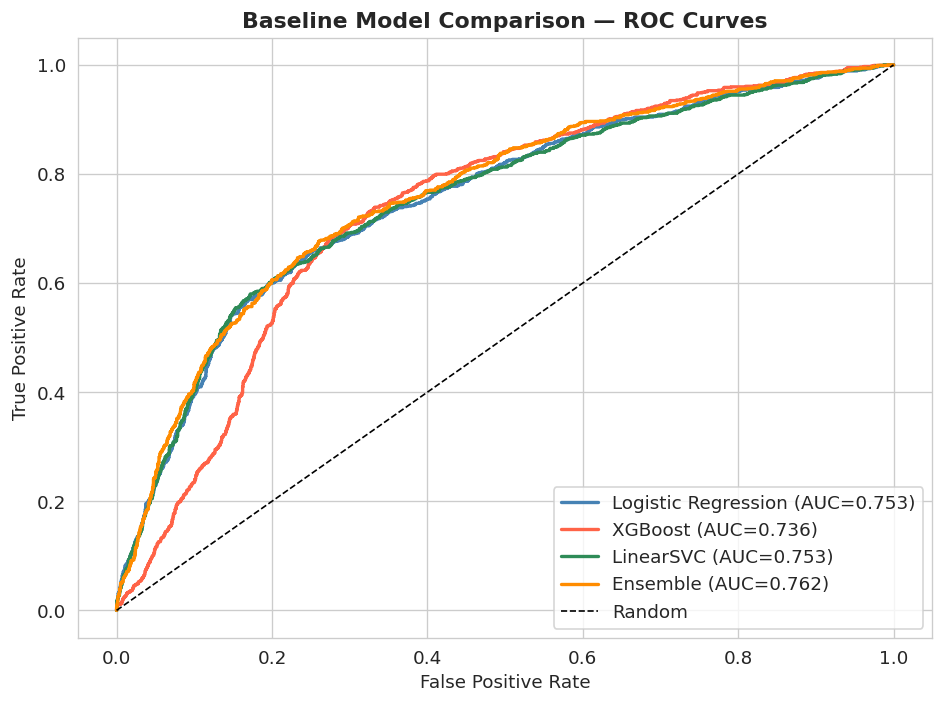

In [20]:
# Plot ROC curves for all models on one chart
# Visual comparison of discrimination ability across all thresholds

plt.figure(figsize=(8, 6))

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['probs'])
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={res['auc']:.3f})",
             color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline Model Comparison — ROC Curves', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/figures/09_baseline_roc.png', dpi=150, bbox_inches='tight')
plt.show()

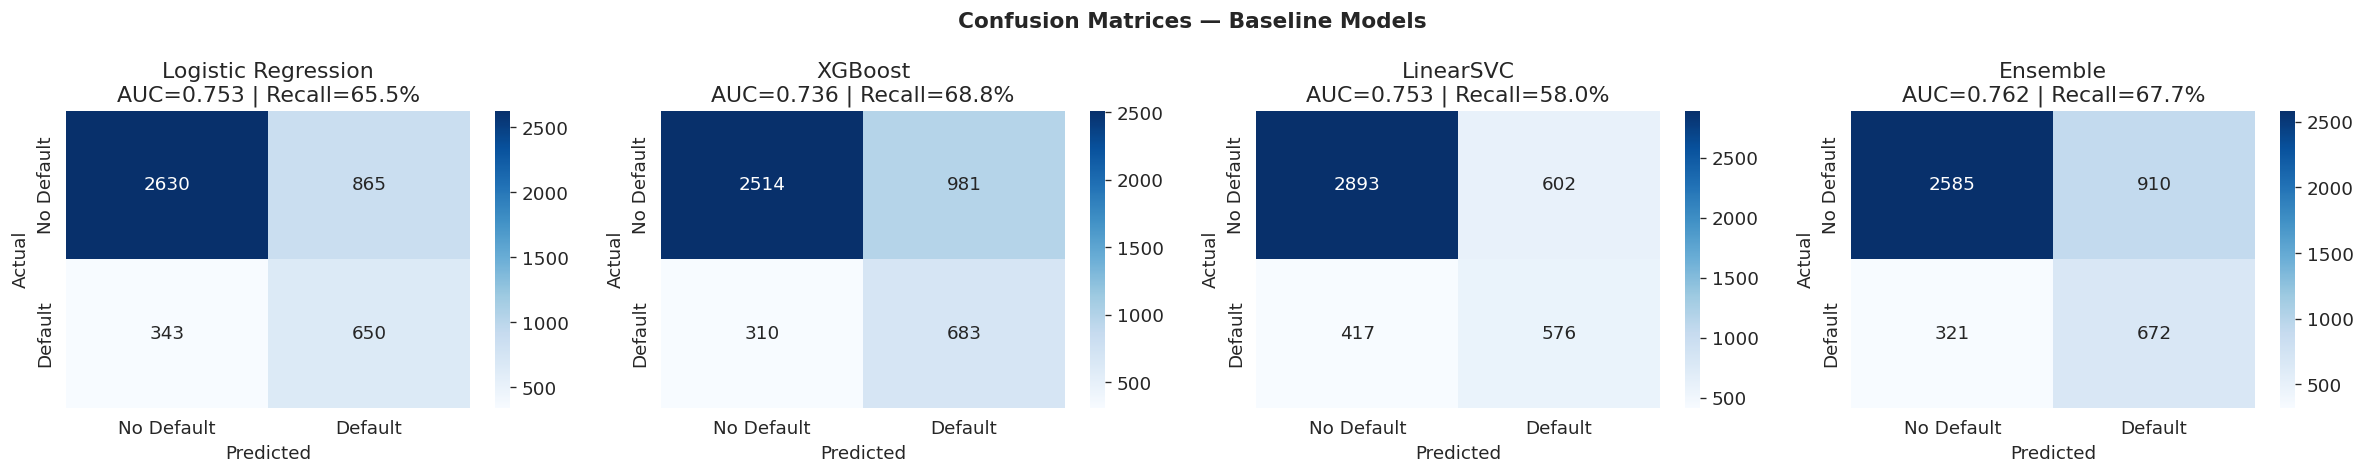

In [21]:
# Plot confusion matrices side by side for all 4 models
# Shows trade-off between TP, FP, FN, TN visually

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', ax=ax,
        xticklabels=['No Default', 'Default'],
        yticklabels=['No Default', 'Default'],
        cmap='Blues'
    )
    ax.set_title(f"{name}\nAUC={res['auc']:.3f} | Recall={res['recall']:.1%}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Baseline Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/10_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Print clean summary table of all baseline results
# This becomes the target scorecard for deep learning experiments

print(f"\n{'='*65}")
print(f"{'Model':<25} {'AUC':>8} {'Recall':>8} {'TP':>6} {'FP':>6} {'FN':>6}")
print(f"{'='*65}")

for name, res in results.items():
    marker = ' ← ensemble target' if name == 'Ensemble' else ''
    print(f"{name:<25} {res['auc']:>8.4f} {res['recall']:>8.1%} "
          f"{res['tp']:>6} {res['fp']:>6} {res['fn']:>6}{marker}")

print(f"{'='*65}")
print(f"\nDL model must beat Ensemble AUC: {results['Ensemble']['auc']:.4f}")


Model                          AUC   Recall     TP     FP     FN
Logistic Regression         0.7528    65.5%    650    865    343
XGBoost                     0.7357    68.8%    683    981    310
LinearSVC                   0.7527    58.0%    576    602    417
Ensemble                    0.7619    67.7%    672    910    321 ← ensemble target

DL model must beat Ensemble AUC: 0.7619


## 📋 Baseline Models — Key Findings

### Results Summary

| Model | AUC | Recall | TP | FP | FN |
|---|---|---|---|---|---|
| Logistic Regression | 0.7528 | 65.5% | 650 | 865 | 343 |
| XGBoost | 0.7357 | 68.8% | 683 | 981 | 310 |
| LinearSVC | 0.7527 | 58.0% | 576 | 602 | 417 |
| **Ensemble (Soft Vote)** | **0.7619** | **67.7%** | **672** | **910** | **321** |

### Key Observations

1. **Ensemble wins AUC (0.7619)** by averaging probabilities from all 3 models
2. **NearMiss v3 effectively balanced the dataset**
   - Reduced majority class to match minority class size
   - Improved recall across all models by focusing on boundary samples
3. **Each model has a different strength:**
   - LR: best balance between AUC and FP
   - XGBoost: best recall (68.8%) but most false alarms (981)
   - LinearSVC: lowest false alarms (602) but misses most defaults (417)
4. **Optuna tuning** found non-obvious hyperparameters:
   - LR: very small C (0.112) → strong regularization needed
   - XGB: shallow trees (depth=3) → data is not deeply hierarchical
   - SVC: very small C (0.003) → large margin preferred

### 🎯 Targets for Deep Learning Model

| Metric | Target |
|---|---|
| AUC | > 0.7619 |
| Recall | > 67.7% |
| False Positives | < 910 |
| False Negatives | < 321 |

### Pipeline Used
- **Feature engineering:** 17 domain-specific features (40 total)
- **Resampling:** NearMiss v3 (n_neighbors=3)
- **Tuning:** Optuna TPE sampler (50 trials each)
- **Ensemble:** Soft voting (equal weights)